In [1]:
def _kf_apply_doc_styles() -> None:
    from pathlib import Path
    import kfactory.utilities
    import kfactory.widgets.interactive

    _lyp = Path('/home/runner/work/kfactory/kfactory/docs/source-built/_static/doc_styles.lyp')
    if not _lyp.is_file():
        return
    _original = kfactory.utilities.as_png_data

    def _styled_as_png_data(c, layer_properties=None, **kwargs):
        return _original(c, layer_properties=layer_properties or str(_lyp), **kwargs)

    kfactory.utilities.as_png_data = _styled_as_png_data
    kfactory.widgets.interactive.as_png_data = _styled_as_png_data


_kf_apply_doc_styles()


# Routing Overview

kfactory provides routing utilities for connecting component ports with wires or
waveguides. All routers live under `kf.routing`:

| Sub-module | Purpose |
|---|---|
| `kf.routing.optical` | Photonic/optical waveguides — uses bends (euler, circular) |
| `kf.routing.electrical` | Metal wires — right-angle corners only |
| `kf.routing.aa.optical` | All-angle optical routing (non-Manhattan) |

The primary entry point in each module is **`route_bundle`**, which routes *N* start
ports to *N* end ports while avoiding obstacles.

## Port angle convention

A port's angle is the **outward** direction — the direction a wire exits the device at
that port.  `route_bundle` connects:

- **Start** ports: wire exits in the direction of the port's angle.
- **End** ports: wire arrives going in the direction of the port's angle.

The most common pairing is start facing North (angle=1) and end facing South (angle=3)
with end ports above start ports, which produces S-shaped routes.
Alternatively, start and end can face the same direction when one port sits directly
"in front" of the other (e.g., two East-facing ports on a horizontal axis).

KLayout angle integers: `0` = East (0°), `1` = North (90°), `2` = West (180°),
`3` = South (270°).

In [2]:
from functools import partial

import kfactory as kf


# ── Layers ────────────────────────────────────────────────────────────────
# Use kf.kcl (the global layout) and register all layers on it.
# Ports, cells, and factories all need to share the same KCLayout instance.
class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    WGCLAD: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)
    METAL: kf.kdb.LayerInfo = kf.kdb.LayerInfo(20, 0)
    METALEX: kf.kdb.LayerInfo = kf.kdb.LayerInfo(20, 1)
    FLOORPLAN: kf.kdb.LayerInfo = kf.kdb.LayerInfo(10, 0)


L = LAYER()
kf.kcl.infos = L

# ── Optical waveguide setup ───────────────────────────────────────────────
wg_enc = kf.kcl.get_enclosure(
    kf.LayerEnclosure(name="WGSTD", sections=[(L.WGCLAD, 0, 2_000)])
)

# Euler bend cell (angle=90, radius=10 µm).
# bend_euler_factory takes width and radius in µm.
bend90 = kf.factories.euler.bend_euler_factory(kcl=kf.kcl)(
    width=0.5,  # µm
    radius=10,  # µm
    layer=L.WG,
    enclosure=wg_enc,
    angle=90,
)

# Straight factory: call with width= and length= in DBU
straight_factory = partial(
    kf.factories.straight.straight_dbu_factory(kcl=kf.kcl),
    layer=L.WG,
    enclosure=wg_enc,
)

# Convenience: 0.5 µm port width in DBU
WG_WIDTH = kf.kcl.to_dbu(0.5)  # 500 DBU at 1 nm/DBU

## 1 · Straight (degenerate) route

When two East-facing ports sit on the same horizontal axis, `route_bundle` places
a single straight waveguide with no bends.

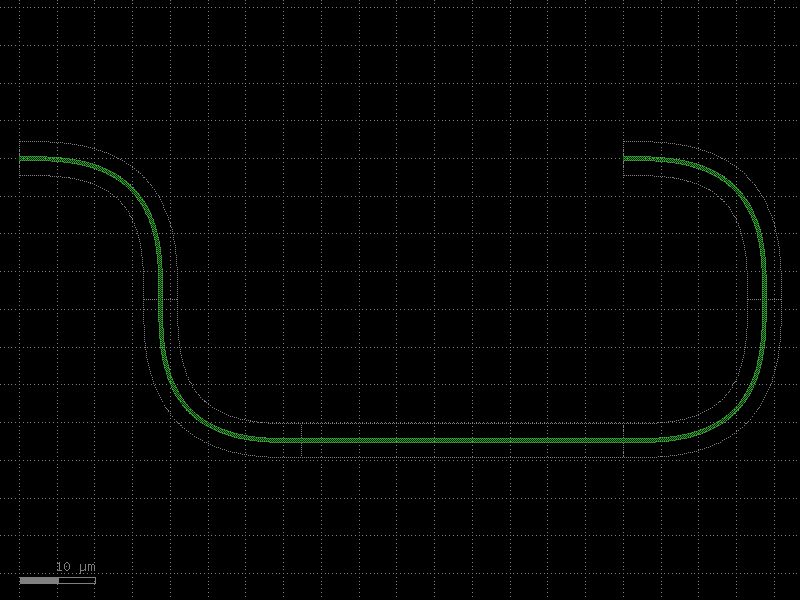

In [3]:
c_straight = kf.KCell("route_straight")

p1 = kf.Port(
    name="o1",
    trans=kf.kdb.Trans(0, False, 0, 0),
    width=WG_WIDTH,
    layer_info=L.WG,
)
p2 = kf.Port(
    name="o2",
    trans=kf.kdb.Trans(0, False, kf.kcl.to_dbu(80), 0),
    width=WG_WIDTH,
    layer_info=L.WG,
)

kf.routing.optical.route_bundle(
    c_straight,
    [p1],
    [p2],
    separation=kf.kcl.to_dbu(5),
    straight_factory=straight_factory,
    bend90_cell=bend90,
)
c_straight

## 2 · Single route with bends

Start facing North (angle=1), end facing South (angle=3), end above start.  The
router inserts euler bends to produce an S-shaped path.

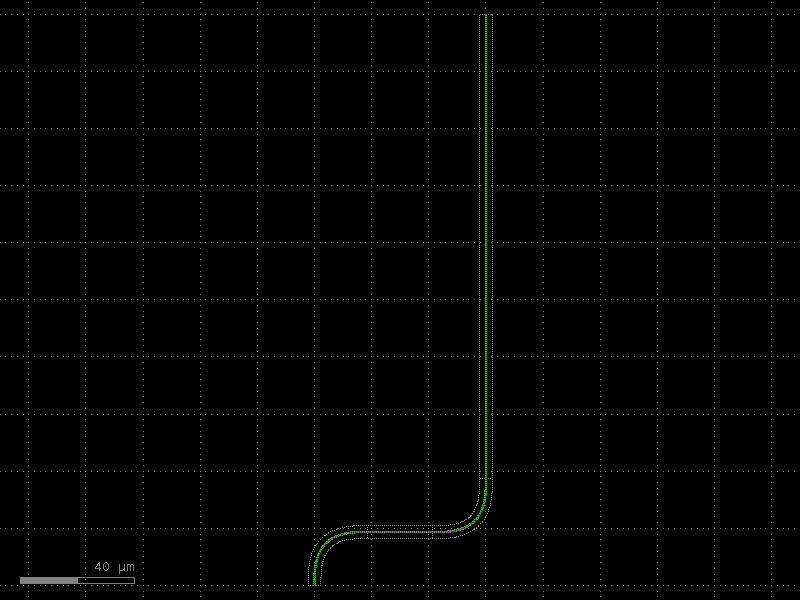

In [4]:
c1 = kf.KCell("single_route_bend")

p_start = kf.Port(
    name="o1",
    trans=kf.kdb.Trans(1, False, 0, 0),
    width=WG_WIDTH,
    layer_info=L.WG,
)
p_end = kf.Port(
    name="o2",
    trans=kf.kdb.Trans(3, False, kf.kcl.to_dbu(60), kf.kcl.to_dbu(200)),
    width=WG_WIDTH,
    layer_info=L.WG,
)

kf.routing.optical.route_bundle(
    c1,
    [p_start],
    [p_end],
    separation=kf.kcl.to_dbu(5),
    straight_factory=straight_factory,
    bend90_cell=bend90,
)
c1

## 3 · Bundle routing

Route multiple waveguides in parallel.  kfactory fans the routes apart to maintain
at least `separation` between adjacent route edges.

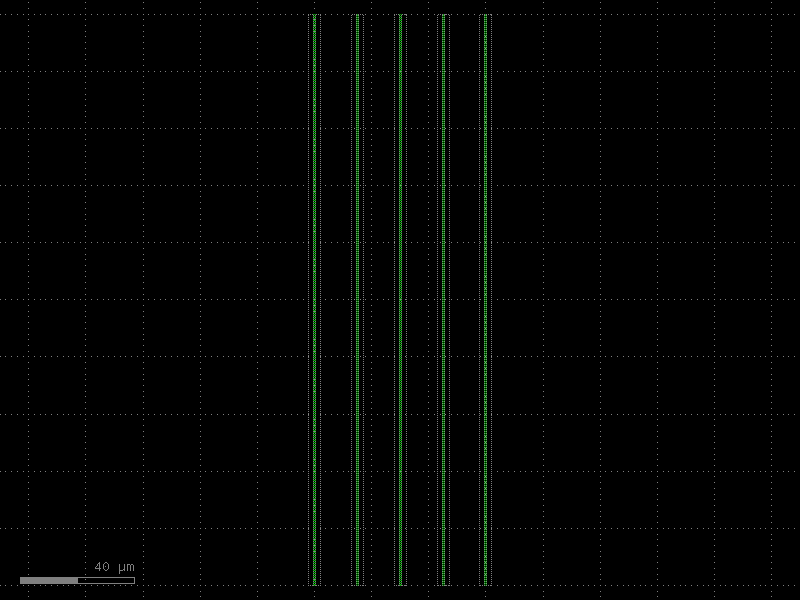

In [5]:
c2 = kf.KCell("bundle_route")

n = 5
start_ports = [
    kf.Port(
        name=f"in_{i}",
        trans=kf.kdb.Trans(1, False, kf.kcl.to_dbu(i * 15), 0),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i in range(n)
]
end_ports = [
    kf.Port(
        name=f"out_{i}",
        trans=kf.kdb.Trans(3, False, kf.kcl.to_dbu(i * 15), kf.kcl.to_dbu(200)),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i in range(n)
]

kf.routing.optical.route_bundle(
    c2,
    start_ports,
    end_ports,
    separation=kf.kcl.to_dbu(5),
    straight_factory=straight_factory,
    bend90_cell=bend90,
)
c2

## 4 · Obstacle avoidance

Pass `bboxes` to mark keep-out zones.  The router automatically detours around them.

> **Caveat**: the obstacle bbox must overlap (or touch) the bundle's own
> bounding box for the detour to take effect — an isolated box floating in
> empty space between the two port groups is ignored.  In the example below
> the obstacle covers the left-most start port, so the bundle must deflect
> around it.  Rotating the end ports by 90° (East-facing instead of
> South-facing) makes the resulting detour visually obvious.

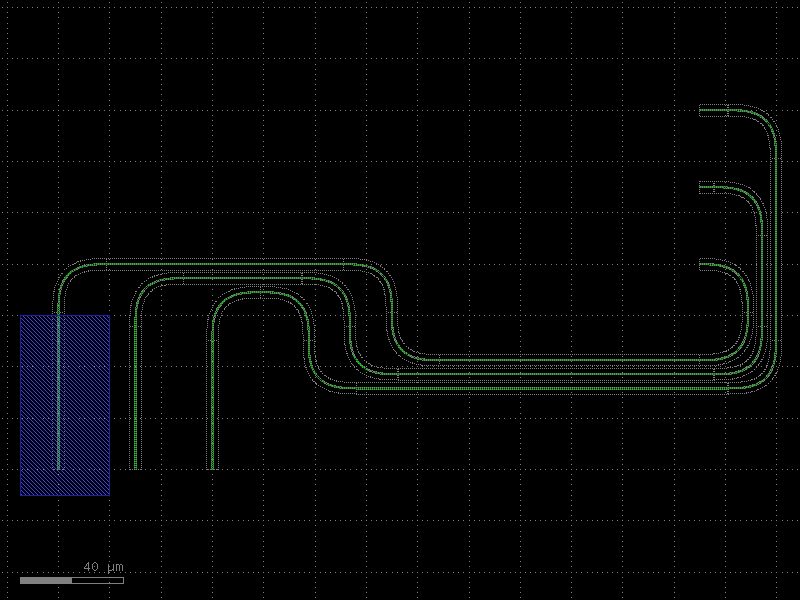

In [6]:
c3 = kf.KCell("obstacle_avoidance")

# Start ports face North at the bottom; end ports face East on the right.
start_ports3 = [
    kf.Port(
        name=f"in_{i}",
        trans=kf.kdb.Trans(1, False, kf.kcl.to_dbu(i * 30), 0),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i in range(3)
]
end_ports3 = [
    kf.Port(
        name=f"out_{i}",
        trans=kf.kdb.Trans(0, False, kf.kcl.to_dbu(250), kf.kcl.to_dbu(80 + i * 30)),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i in range(3)
]

# Obstacle covers the left-most start port — it touches the bundle bbox, so
# the router has to route around it.
obstacle = kf.kdb.Box(
    kf.kcl.to_dbu(-15),
    kf.kcl.to_dbu(-10),
    kf.kcl.to_dbu(20),
    kf.kcl.to_dbu(60),
)
c3.shapes(kf.kcl.find_layer(L.FLOORPLAN)).insert(obstacle)

kf.routing.optical.route_bundle(
    c3,
    start_ports3,
    end_ports3,
    separation=kf.kcl.to_dbu(5),
    straight_factory=straight_factory,
    bend90_cell=bend90,
    bboxes=[obstacle],
)
c3

## 5 · Electrical routing

Electrical routes are plain Manhattan wires — no bend cells needed.  Use
`kf.routing.electrical.route_bundle` with `place_layer` and `route_width` (in DBU).

To make the routing non-trivial we orient the start ports North-facing along
the bottom edge and the end ports East-facing on the right edge — the
resulting L-shaped wires demonstrate that the electrical router does insert
right-angle corners.

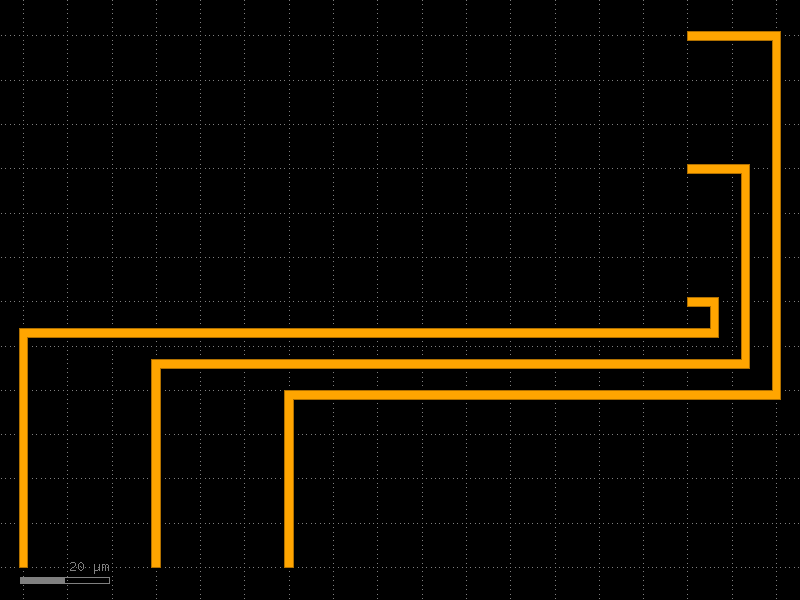

In [7]:
METAL_WIDTH = 2_000  # 2 µm in DBU

ce = kf.KCell("electrical_bundle")

e_start = [
    kf.Port(
        name=f"e_in_{i}",
        trans=kf.kdb.Trans(1, False, i * 30_000, 0),
        width=METAL_WIDTH,
        layer_info=L.METAL,
    )
    for i in range(3)
]
# End ports face East, offset along y so each wire must bend to reach its
# target.
e_end = [
    kf.Port(
        name=f"e_out_{i}",
        trans=kf.kdb.Trans(0, False, 150_000, 60_000 + i * 30_000),
        width=METAL_WIDTH,
        layer_info=L.METAL,
    )
    for i in range(3)
]

kf.routing.electrical.route_bundle(
    ce,
    e_start,
    e_end,
    separation=5_000,
    place_layer=L.METAL,
)
ce

## Summary

| Task | API |
|---|---|
| Route *N* optical waveguides | `kf.routing.optical.route_bundle(c, starts, ends, sep, straight_factory=..., bend90_cell=...)` |
| Route *N* metal wires | `kf.routing.electrical.route_bundle(c, starts, ends, sep, place_layer=...)` |
| Avoid obstacles | add `bboxes=[kdb.Box(...)]` to `route_bundle` |
| U-turn loopback (with GCs) | see [Routing: Optical § 4](optical.py) |

All coordinates in `KCell`-based APIs are in **DBU** (1 nm = 1 DBU with default `dbu = 0.001`).
Use `kf.kcl.to_dbu(x_um)` to convert from µm.  For a purely µm-native workflow use
`DKCell` / `DPort` variants instead.

## See Also

| Topic | Where |
|-------|-------|
| Optical route options: waypoints, path-length matching, loopbacks | [Routing: Optical](optical.py) |
| Electrical (metal wire) routing | [Routing: Electrical](electrical.py) |
| Manhattan backbone algorithm and Steps API | [Routing: Manhattan](manhattan.py) |
| All-angle (diagonal) routing | [Routing: All-Angle](all_angle.py) |
| Bundle routing: sort, separation, sbend, bbox modes | [Routing: Bundle](bundle.py) |
| Equal path-length routing | [Routing: Path Length](path_length.py) |
| Euler bend cells and effective radius | [Components: Euler Bends](../components/cells/factories/euler.py) |
| DBU vs µm coordinate systems | [Core Concepts: DBU vs µm](../concepts/dbu_vs_um.py) |